In [1]:
# makemore
# makemore takes one text file as input, where each line is assumed to be one training thing, and generates more things like it. Under the hood, it is an autoregressive character-level language model, with a wide choice of models from bigrams all the way to a Transformer (exactly as seen in GPT). 

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
min(len(w) for w in words)

2

In [6]:
max(len(w) for w in words)

15

In [7]:
for w in words[:1]:
    for ch1, ch2 in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a


In [8]:
words[:3]

['emma', 'olivia', 'ava']

In [9]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [10]:
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [11]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [91]:
list(b.items())[:3]

[(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168)]

In [93]:
q = sorted(b.items(), key = lambda kv: -kv[1])
list(q)[:3]

[(('n', '<E>'), 6763), (('a', '<E>'), 6640), (('a', 'n'), 5438)]

In [14]:
import torch
N = torch.zeros((28, 28), dtype = torch.int32)

In [15]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}

In [94]:
list(stoi.items())[:3]

[('a', 1), ('b', 2), ('c', 3)]

In [17]:
stoi['<S>'] = 26
stoi['<E>'] = 27

In [18]:
for w in words: 
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [95]:
N[1]

tensor([6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
        2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
         182, 2050,  435], dtype=torch.int32)

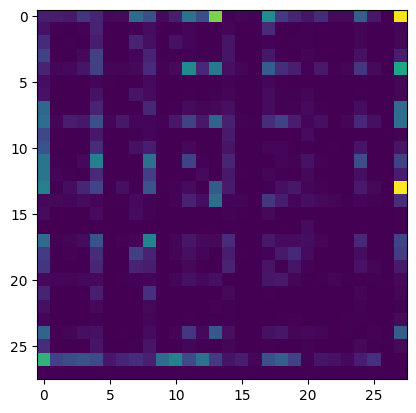

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [21]:
itos = {i:s for s, i in stoi.items()}
itos

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '<S>',
 27: '<E>'}

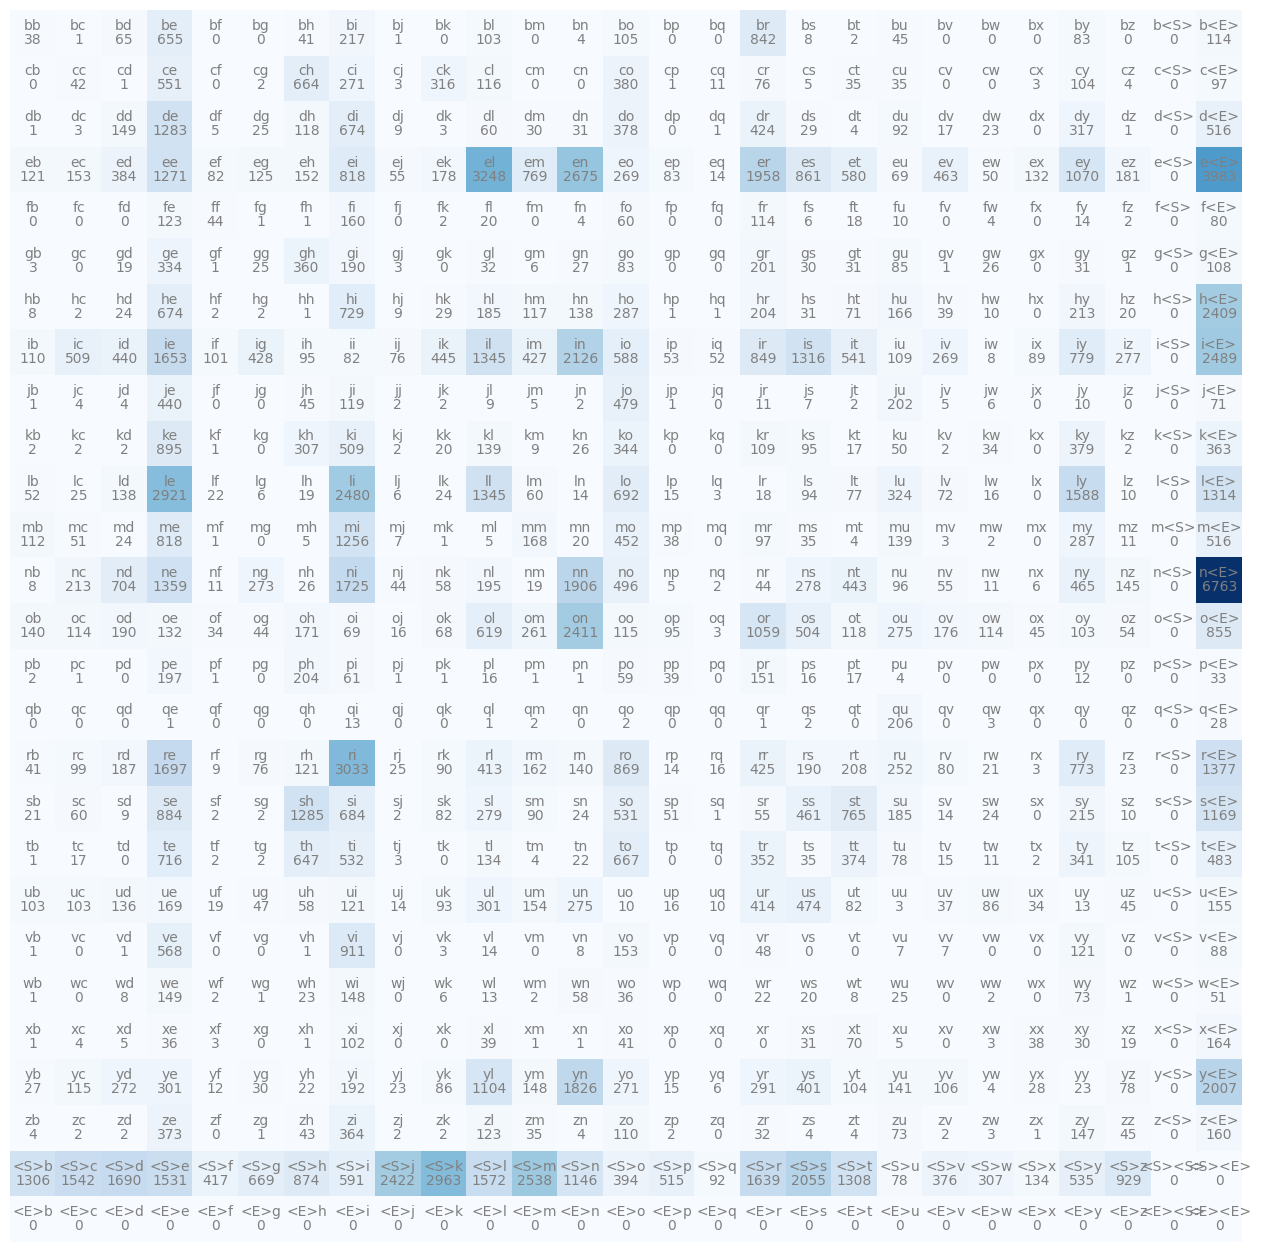

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N[1:, 1:], cmap = 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i+1] + itos[j+1]
        plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'gray')
        plt.text(j, i, N[i+1, j+1].item(), ha = 'center', va = 'top', color = 'gray')
        
plt.axis('off');

In [23]:
len(itos)

28

In [24]:
N.shape

torch.Size([28, 28])

In [25]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [26]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [27]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

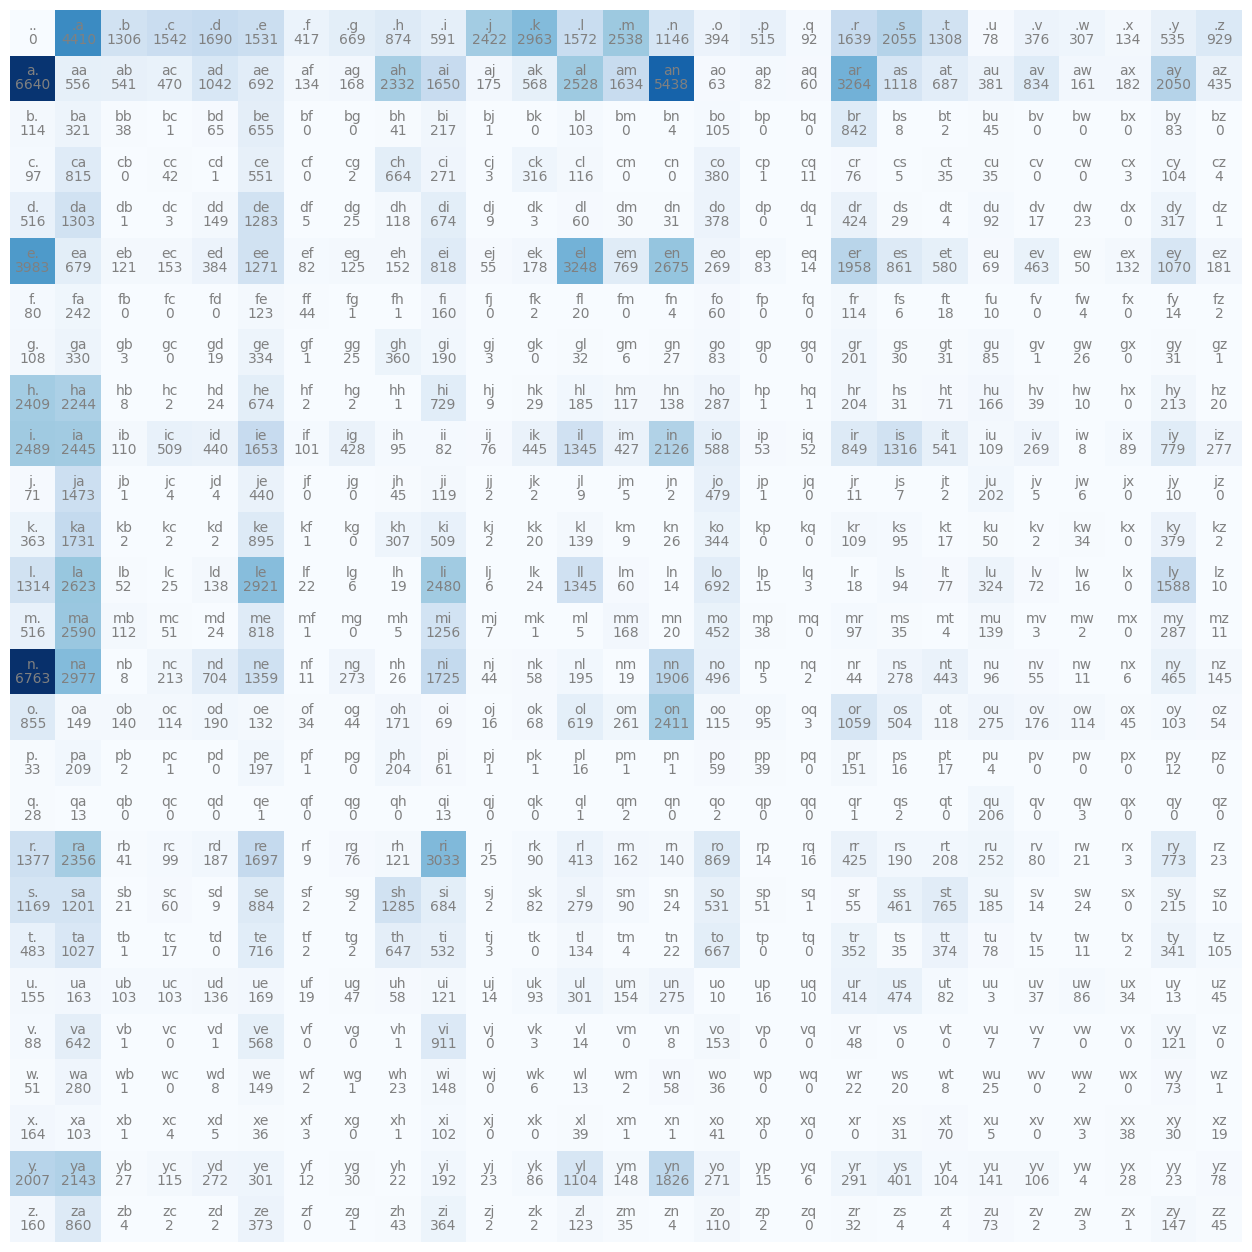

In [28]:
N = torch.zeros((27, 27), dtype = torch.int32)
for w in words: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
        
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap = 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'gray')
        plt.text(j, i, N[i, j].item(), ha = 'center', va = 'top', color = 'gray')
        
plt.axis('off');

In [29]:
print(itos[0])

.


In [30]:
print(len(itos))

27


In [31]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [32]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [33]:
p.sum()

tensor(1.)

In [34]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()

In [35]:
p

tensor([0.6064, 0.3033, 0.0903])

In [36]:
p.shape

torch.Size([3])

In [37]:
P = N.float()
P.sum()

tensor(228146.)

In [38]:
P.sum(0, keepdim=True).shape

torch.Size([1, 27])

In [39]:
P.sum(1, keepdim=True)

tensor([[32033.],
        [33885.],
        [ 2645.],
        [ 3532.],
        [ 5496.],
        [20423.],
        [  905.],
        [ 1927.],
        [ 7616.],
        [17701.],
        [ 2900.],
        [ 5040.],
        [13958.],
        [ 6642.],
        [18327.],
        [ 7934.],
        [ 1026.],
        [  272.],
        [12700.],
        [ 8106.],
        [ 5570.],
        [ 3135.],
        [ 2573.],
        [  929.],
        [  697.],
        [ 9776.],
        [ 2398.]])

In [40]:
P[0].sum()

tensor(32033.)

In [41]:
# broadcasting
P.sum(1).shape

torch.Size([27])

In [96]:
P = P / P.sum(1, keepdim=True)
P[1]

tensor([0.1255, 0.0256, 0.0253, 0.0241, 0.0335, 0.0278, 0.0186, 0.0192, 0.0547,
        0.0435, 0.0193, 0.0258, 0.0579, 0.0433, 0.1057, 0.0175, 0.0178, 0.0174,
        0.0700, 0.0348, 0.0277, 0.0227, 0.0301, 0.0191, 0.0194, 0.0501, 0.0236])

In [43]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [97]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [98]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexzmaloglkurkicqzktyhwmvmzimjttainrlkfukzka.
da.
staxvpubjtbhrygotzi.
mczieqckvujkwpteda.
ka.
emkmmsadguenkavgynywftbspmhwcivgbvtahlvsu.
dsdxxblnwglhpyaw.
isan.
jrpfdwipkezkm.
deru.


In [46]:
# max LL ==> min NLL
log_likehood = 0.0
n = 0
for w in words[:3]: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob) 
        log_likehood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')
print(f'log likehood: {log_likehood: .4f}')
nll = -log_likehood
print(f'negative log likehood: {nll: .4f}')
print(f'{nll/n}')

.e:  0.0478 -3.0408
em:  0.0377 -3.2793
mm:  0.0253 -3.6772
ma:  0.3899 -0.9418
a.:  0.1960 -1.6299
.o:  0.0123 -4.3982
ol:  0.0780 -2.5508
li:  0.1777 -1.7278
iv:  0.0152 -4.1867
vi:  0.3541 -1.0383
ia:  0.1381 -1.9796
a.:  0.1960 -1.6299
.a:  0.1377 -1.9829
av:  0.0246 -3.7045
va:  0.2495 -1.3882
a.:  0.1960 -1.6299
log likehood: -38.7856
negative log likehood:  38.7856
2.424102306365967


In [47]:
log_likehood = 0.0
n = 0
for w in ["andrej"]: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob) 
        log_likehood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')
print(f'log likehood: {log_likehood: .4f}')
nll = -log_likehood
print(f'negative log likehood: {nll: .4f}')
print(f'{nll/n}')

.a:  0.1377 -1.9829
an:  0.1605 -1.8296
nd:  0.0384 -3.2594
dr:  0.0771 -2.5620
re:  0.1336 -2.0127
ej:  0.0027 -5.9171
j.:  0.0245 -3.7098
log likehood: -21.2735
negative log likehood:  21.2735
3.03906512260437


In [99]:
P = (N+1000).float()
P[1]

tensor([7640., 1556., 1541., 1470., 2042., 1692., 1134., 1168., 3332., 2650.,
        1175., 1568., 3528., 2634., 6438., 1063., 1082., 1060., 4264., 2118.,
        1687., 1381., 1834., 1161., 1182., 3050., 1435.])

In [49]:
# create the training set of bigrams (x,y)
xs, ys = [], []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [50]:
xs

tensor([ 0,  5, 13, 13,  1])

In [51]:
ys

tensor([ 5, 13, 13,  1,  0])

In [52]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes = 27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [53]:
xenc.shape

torch.Size([5, 27])

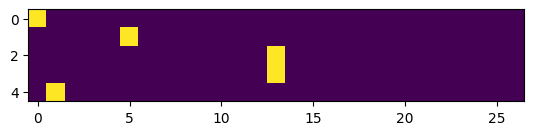

In [54]:
plt.imshow(xenc)

In [55]:
xenc.dtype

torch.float32

In [56]:
W = torch.randn((27, 1))

In [57]:
xenc @ W

tensor([[-0.2846],
        [ 0.5486],
        [-1.0261],
        [-1.0261],
        [-1.0612]])

In [58]:
(xenc @ W)[3, 13]

IndexError: index 13 is out of bounds for dimension 1 with size 1

In [59]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [60]:
W[:, 13]

IndexError: index 13 is out of bounds for dimension 1 with size 1

In [61]:
(xenc @ W).exp()

tensor([[0.7523],
        [1.7309],
        [0.3584],
        [0.3584],
        [0.3460]])

In [62]:
W = torch.randn((27, 27))
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs

tensor([[0.0188, 0.1991, 0.0237, 0.0116, 0.0066, 0.0037, 0.0180, 0.0091, 0.0285,
         0.0737, 0.0267, 0.0976, 0.0017, 0.0130, 0.0204, 0.0289, 0.0080, 0.0145,
         0.0051, 0.0087, 0.0234, 0.0193, 0.0100, 0.1588, 0.1468, 0.0091, 0.0153],
        [0.0085, 0.0149, 0.0061, 0.0034, 0.0100, 0.0337, 0.0623, 0.1199, 0.0303,
         0.0349, 0.0128, 0.0290, 0.0181, 0.0483, 0.0249, 0.0141, 0.0177, 0.0774,
         0.0139, 0.0177, 0.0350, 0.0215, 0.0640, 0.0130, 0.0076, 0.0519, 0.2091],
        [0.0274, 0.0570, 0.0142, 0.0248, 0.0309, 0.0478, 0.0061, 0.0101, 0.0551,
         0.0092, 0.0090, 0.0731, 0.0351, 0.0103, 0.0868, 0.0193, 0.0718, 0.0419,
         0.0917, 0.0551, 0.0699, 0.0143, 0.0467, 0.0174, 0.0369, 0.0089, 0.0293],
        [0.0274, 0.0570, 0.0142, 0.0248, 0.0309, 0.0478, 0.0061, 0.0101, 0.0551,
         0.0092, 0.0090, 0.0731, 0.0351, 0.0103, 0.0868, 0.0193, 0.0718, 0.0419,
         0.0917, 0.0551, 0.0699, 0.0143, 0.0467, 0.0174, 0.0369, 0.0089, 0.0293],
        [0.0261, 0.0049,

In [63]:
probs[0]

tensor([0.0188, 0.1991, 0.0237, 0.0116, 0.0066, 0.0037, 0.0180, 0.0091, 0.0285,
        0.0737, 0.0267, 0.0976, 0.0017, 0.0130, 0.0204, 0.0289, 0.0080, 0.0145,
        0.0051, 0.0087, 0.0234, 0.0193, 0.0100, 0.1588, 0.1468, 0.0091, 0.0153])

In [64]:
probs[0].sum()

tensor(1.0000)

In [65]:
probs[0].shape

torch.Size([27])

In [66]:
probs.shape

torch.Size([5, 27])

In [67]:
nlls = torch.zeros(5)
for i in range(5):
    # i=th bigram
    x = xs[i].item() # input character index
    y = ys[i].item() # output character index
    print('----------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes: {x} {y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct next character:', p.item())
    logp = torch.log(p)
    print('log probability:', logp.item())
    nll = -logp
    print('negative log likehood:', nll.item())
    nlls[i] = nll
    
print('======')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

----------
bigram example 1: .e (indexes: 0 5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0188, 0.1991, 0.0237, 0.0116, 0.0066, 0.0037, 0.0180, 0.0091, 0.0285,
        0.0737, 0.0267, 0.0976, 0.0017, 0.0130, 0.0204, 0.0289, 0.0080, 0.0145,
        0.0051, 0.0087, 0.0234, 0.0193, 0.0100, 0.1588, 0.1468, 0.0091, 0.0153])
label (actual next character): 5
probability assigned by the net to the correct next character: 0.003659037873148918
log probability: -5.610555171966553
negative log likehood: 5.610555171966553
----------
bigram example 2: em (indexes: 5 13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0085, 0.0149, 0.0061, 0.0034, 0.0100, 0.0337, 0.0623, 0.1199, 0.0303,
        0.0349, 0.0128, 0.0290, 0.0181, 0.0483, 0.0249, 0.0141, 0.0177, 0.0774,
        0.0139, 0.0177, 0.0350, 0.0215, 0.0640, 0.0130, 0.0076, 0.0519, 0.2091])
label (actual next character): 13
probability assigned by the net to the correct next chara

In [68]:
# optimization

In [69]:
xs

tensor([ 0,  5, 13, 13,  1])

In [70]:
ys

tensor([ 5, 13, 13,  1,  0])

In [71]:
# randomly initialize 27 neurons' weights, each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [72]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
# backward pass
loss = -probs[torch.arange(5), ys].log().mean()

In [73]:
probs.shape

torch.Size([5, 27])

In [74]:
# backward pass
W.grad = None # set the gradient to zero
loss.backward()

In [75]:
probs[0, 5], probs[1, 13], probs[2, 13]

(tensor(0.0123, grad_fn=<SelectBackward0>),
 tensor(0.0181, grad_fn=<SelectBackward0>),
 tensor(0.0267, grad_fn=<SelectBackward0>))

In [76]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [77]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

In [78]:
W.shape

torch.Size([27, 27])

In [79]:
W.data += -0.1 * W.grad

In [80]:
# all
# create the training set of bigrams (x,y)
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [100]:
# gradient descent
for k in range(10):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    
    # backward pass
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    print(loss.item())
    W.grad = None
    loss.backward()
    
    # update
    W.data += -50 * W.grad

2.4829330444335938
2.4829113483428955
2.4828898906707764
2.4828689098358154
2.4828481674194336
2.482827663421631
2.482807159423828
2.4827871322631836
2.48276686668396
2.482747793197632


In [84]:
(W**2).sum()

tensor(1271.0992, grad_fn=<SumBackward0>)

In [85]:
(W**2).mean()

tensor(1.7436, grad_fn=<MeanBackward0>)

In [87]:
# finally, sample from the 'neural net model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        # ------
        # BEFROE:
        p = P[ix]
        # ------
        # NOW:
        
        # ------
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
            
    print(''.join(out))

cexzmaloglkurkicqzktyhwmvmzimjttainrlkfukzka.
da.
staxvpubjtbhrygotzi.
mczieqckvujkwpteda.
ka.


In [88]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        # ------
        # BEFROE:
        # p = P[ix]
        # ------
        # NOW:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        # ------
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
            
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
